In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
from datetime import date

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import (
    FunctionTransformer, StandardScaler,
    OneHotEncoder, OrdinalEncoder, PowerTransformer
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import accuracy_score, classification_report,ConfusionMatrixDisplay,confusion_matrix, \
                            precision_score, recall_score, f1_score


warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)


---
## 1. Configuration

In [2]:
DATA_PATH    = 'EasyVisa.csv'
TARGET_COL   = 'case_status'
PROBLEM_TYPE = 'classification'

COLS_TO_DROP = ['case_id','requires_job_training']

BINARY_YN_COLS = ['has_job_experience', 'full_time_position']

ORDINAL_COLS  = ['education_of_employee']
ORDINAL_ORDER = [["High School", "Bachelor's", "Master's", "Doctorate"]]

ONEHOT_COLS = ['continent', 'region_of_employment', 'unit_of_wage']

IMPUTE_MEDIAN = []
IMPUTE_MEAN   = []
IMPUTE_MODE   = []

---
## 2. Load Data

In [3]:
df=pd.read_csv(DATA_PATH)

In [4]:
df.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.20,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.65,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.86,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.03,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.39,Year,Y,Certified


In [5]:
df.shape

(25480, 12)

---
## 3. Drop Useless Columns

In [6]:
# Drop columns
if COLS_TO_DROP:
    df.drop(columns=COLS_TO_DROP,inplace=True)
    print("Dropped columns:", COLS_TO_DROP)

Dropped columns: ['case_id', 'requires_job_training']


In [7]:
print("Shape:", df.shape)

Shape: (25480, 10)


---
## 4. Handle Missing Values

In [8]:
# Median imputation
if IMPUTE_MEDIAN:
    for col in IMPUTE_MEDIAN:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(col, ": filled with median =", round(median_val, 4))

# Mean imputation
if IMPUTE_MEAN:
    for col in IMPUTE_MEAN:
        mean_val = df[col].mean()
        df[col].fillna(mean_val, inplace=True)
        print(col, ": filled with mean =", round(mean_val, 4))

# Mode imputation
if IMPUTE_MODE:
    for col in IMPUTE_MODE:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(col, ": filled with mode =", mode_val)

# Check remaining missing values
remaining = df.isnull().sum()
remaining = remaining[remaining > 0]

if len(remaining) == 0:
    print("\nNo missing values left")
else:
    print("\nMissing values still present:")
    print(remaining)


No missing values left


---
## 5. Data Cleaning

In [9]:
# Check before fix
(df['no_of_employees']<0.).sum()

np.int64(33)

In [10]:
# Fix negative values
df["no_of_employees"] = df["no_of_employees"].abs()

In [11]:
# Check after fix
(df['no_of_employees']<0.).sum()

np.int64(0)

In [12]:
# 4.2 Normalize prevailing_wage to annual salary
# Hour  x 2080 = Annual  (52 weeks x 40 hours)
# Week  x 52   = Annual
# Month x 12   = Annual
# Year  x 1    = Already Annual

wage_multiplier = {
    'Hour': 2080,
    'Week': 52,
    'Month': 12,
    'Year': 1
}

df['prevailing_wage_annual'] = df['prevailing_wage'] * df['unit_of_wage'].map(wage_multiplier)


In [13]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_annual
0,Asia,High School,N,14513,2007,West,592.20,Hour,Y,Denied,1231782.03
1,Asia,Master's,Y,2412,2002,Northeast,83425.65,Year,Y,Certified,83425.65
2,Asia,Bachelor's,N,44444,2008,West,122996.86,Year,Y,Denied,122996.86
3,Asia,Bachelor's,N,98,1897,West,83434.03,Year,Y,Denied,83434.03
4,Africa,Master's,Y,1082,2005,South,149907.39,Year,Y,Certified,149907.39


In [14]:
# 4.3 Drop original wage columns 
df.drop(columns=['prevailing_wage'], inplace=True)

In [15]:
df.shape

(25480, 10)

---
## Feature Engineering — Create New Features


In [16]:
# creating the date object of today's date
todays_date = date.today()
current_year= todays_date.year

In [17]:
REFERENCE_YEAR = 2024

**Subtract current year with year of estab to get company's age**

In [18]:
df['company_age'] = REFERENCE_YEAR - df['yr_of_estab']

In [19]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,yr_of_estab,region_of_employment,unit_of_wage,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,2007,West,Hour,Y,Denied,1231782.03,17
1,Asia,Master's,Y,2412,2002,Northeast,Year,Y,Certified,83425.65,22
2,Asia,Bachelor's,N,44444,2008,West,Year,Y,Denied,122996.86,16
3,Asia,Bachelor's,N,98,1897,West,Year,Y,Denied,83434.03,127
4,Africa,Master's,Y,1082,2005,South,Year,Y,Certified,149907.39,19


In [20]:
# 5.2 Drop yr_of_estab — replaced by company_age
df.drop(columns=['yr_of_estab'], inplace=True)

In [21]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,West,Hour,Y,Denied,1231782.03,17
1,Asia,Master's,Y,2412,Northeast,Year,Y,Certified,83425.65,22
2,Asia,Bachelor's,N,44444,West,Year,Y,Denied,122996.86,16
3,Asia,Bachelor's,N,98,West,Year,Y,Denied,83434.03,127
4,Africa,Master's,Y,1082,South,Year,Y,Certified,149907.39,19


In [22]:
df.shape

(25480, 10)

In [23]:
df.describe()

,no_of_employees,prevailing_wage_annual,company_age
count,25480.00,25480.00,25480.00
mean,5667.09,197391.16,44.59
std,22877.92,578591.67,42.37
min,11.00,100.00,8.00
25%,1022.00,47107.96,19.00
50%,2109.00,82839.46,27.00
75%,3504.00,124825.04,48.00
max,602069.00,14569149.40,224.00


---
## 6. Split X / y — Encode Target

In [24]:
X = df.drop('case_status', axis=1)
y = df['case_status']

In [25]:
X

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,unit_of_wage,full_time_position,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,West,Hour,Y,1231782.03,17
1,Asia,Master's,Y,2412,Northeast,Year,Y,83425.65,22
2,Asia,Bachelor's,N,44444,West,Year,Y,122996.86,16
3,Asia,Bachelor's,N,98,West,Year,Y,83434.03,127
4,Africa,Master's,Y,1082,South,Year,Y,149907.39,19
...,...,...,...,...,...,...,...,...,...
25475,Asia,Bachelor's,Y,2601,South,Year,Y,77092.57,16
25476,Asia,High School,Y,3274,Northeast,Year,Y,279174.79,18
25477,Asia,Master's,Y,1121,South,Year,N,146298.85,114
25478,Asia,Master's,Y,1918,West,Year,Y,86154.77,137


In [26]:
y

0           Denied
1        Certified
2           Denied
3           Denied
4        Certified
           ...    
25475    Certified
25476    Certified
25477    Certified
25478    Certified
25479    Certified
Name: case_status, Length: 25480, dtype: object

**Manual encoding target column**

In [27]:
y = np.where(y == 'Certified', 1, 0)

In [28]:
y

array([0, 1, 0, ..., 1, 1, 1], shape=(25480,))

In [29]:
df.head()

,continent,education_of_employee,has_job_experience,no_of_employees,region_of_employment,unit_of_wage,full_time_position,case_status,prevailing_wage_annual,company_age
0,Asia,High School,N,14513,West,Hour,Y,Denied,1231782.03,17
1,Asia,Master's,Y,2412,Northeast,Year,Y,Certified,83425.65,22
2,Asia,Bachelor's,N,44444,West,Year,Y,Denied,122996.86,16
3,Asia,Bachelor's,N,98,West,Year,Y,Denied,83434.03,127
4,Africa,Master's,Y,1082,South,Year,Y,Certified,149907.39,19


In [30]:
numerical_features   = [c for c in X.columns if X[c].dtype != 'O']
categorical_features = [c for c in X.columns if X[c].dtype == 'O']
discrete_features    = [c for c in numerical_features if X[c].nunique() <= 25]
continuous_features  = [c for c in numerical_features if X[c].nunique() >  25]

print('Numerical   :', numerical_features)
print('Categorical :', categorical_features)
print('Continuous  :', continuous_features)
print('Discrete    :', discrete_features)

Numerical   : ['no_of_employees', 'prevailing_wage_annual', 'company_age']
Categorical : ['continent', 'education_of_employee', 'has_job_experience', 'region_of_employment', 'unit_of_wage', 'full_time_position']
Continuous  : ['no_of_employees', 'prevailing_wage_annual', 'company_age']
Discrete    : []


---
## 7. Train-Test Split


In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify= y )

In [34]:
print(X_train.shape,X_test.shape)

(20384, 9) (5096, 9)


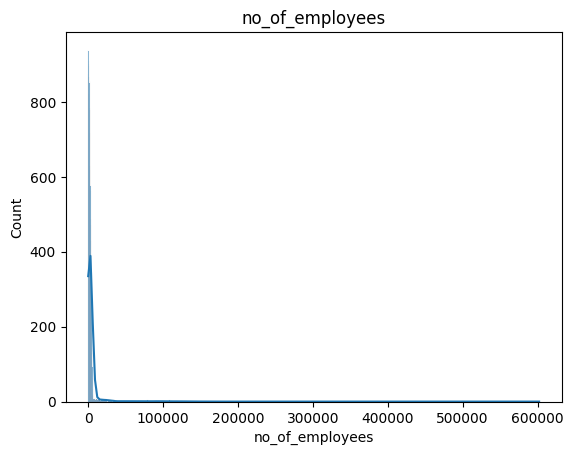

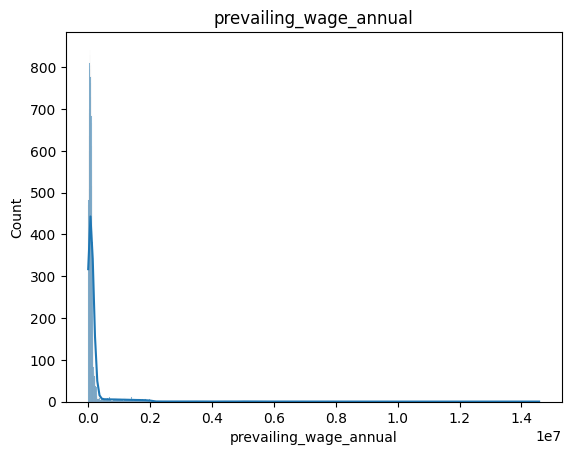

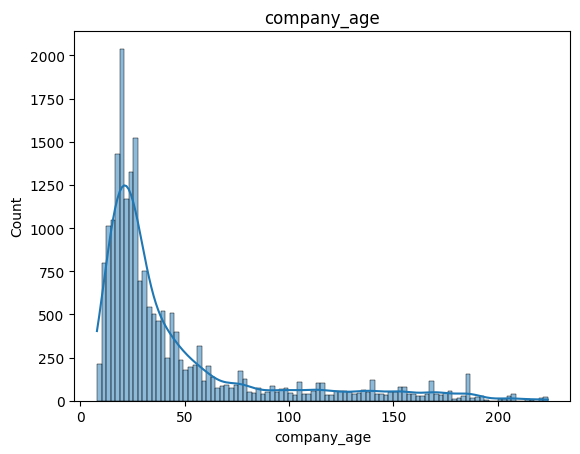

Skewness (X_train):
no_of_employees          12.54
prevailing_wage_annual    8.98
company_age               2.03
dtype: float64


In [35]:
for col in continuous_features:
    sns.histplot(X_train[col], kde=True)
    plt.title(col)
    plt.show()

print("Skewness (X_train):")
print(X_train[continuous_features].skew().round(2))

In [36]:
outlier_list = []

for col in continuous_features:
    Q1 = X_train[col].quantile(0.25)
    Q3 = X_train[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = ((X_train[col] < lower) | (X_train[col] > upper)).sum()
    pct = (count / len(X_train)) * 100

    if pct < 5:
        action = "Cap"
    else:
        action = "Investigate"

    outlier_list.append([col, round(pct, 2), action])

outlier_df = pd.DataFrame(outlier_list, columns=["Column", "Outlier %", "Action"])
print(outlier_df)

                   Column  Outlier %       Action
0         no_of_employees       5.91  Investigate
1  prevailing_wage_annual       9.45  Investigate
2             company_age      12.48  Investigate


In [37]:
for col in continuous_features:
    print("=" * 50)
    print(f"Column: {col}")
    print("=" * 50)
    
    print("\nTop 5 values:")
    print(X_train[col].sort_values(ascending=False).head().to_string(index=False))
    
    print("\nLowest 5 values:")
    print(X_train[col].sort_values().head().to_string(index=False))
    
    print("\n")

Column: no_of_employees

Top 5 values:
602069
581468
579004
547172
499720

Lowest 5 values:
11
11
11
11
11


Column: prevailing_wage_annual

Top 5 values:
14569149.40
12189130.72
11957436.40
10074525.76
 9959159.60

Lowest 5 values:
100.00
104.17
113.96
115.81
126.28


Column: company_age

Top 5 values:
224
224
224
224
224

Lowest 5 values:
8
8
8
8
8




Outlier investigation showed that extreme values in features like number of employees, wage, and company age are realistic and represent valid real-world scenarios. Therefore, these are natural outliers and were handled using log transformation instead of removal or capping.

| Method           | Effect            |
|------------------|------------------|
| Remove outliers  | Reduces skew     |
| Cap outliers     | Reduces skew     |
| Log transform    | Reduces skew ✔   |

---
##  Custom Winsorizer — sklearn-compatible Transformer


In [38]:
# class Winsorizer(BaseEstimator, TransformerMixin):
#     """
#     Clips each column to [lower_quantile, upper_quantile] learned from X_train.

#     Parameters
#     ----------
#     lower : float  lower quantile  (e.g. 0.01 = 1st percentile)
#     upper : float  upper quantile  (e.g. 0.99 = 99th percentile)
#     """
#     def __init__(self, lower=0.01, upper=0.99):
#         self.lower = lower
#         self.upper = upper

#     def fit(self, X, y=None):
#         X = np.asarray(X, dtype=float)
#         self.n_features_in_ = X.shape[1]          # ← required for fallback names
#         self.lower_bounds_  = np.percentile(X, self.lower * 100, axis=0)
#         self.upper_bounds_  = np.percentile(X, self.upper * 100, axis=0)
#         return self

#     def transform(self, X):
#         X = np.asarray(X, dtype=float).copy()
#         return np.clip(X, self.lower_bounds_, self.upper_bounds_)

#     def get_feature_names_out(self, input_features=None):
#         # 1-to-1 transform: output names = input names
#         if input_features is not None:
#             return np.asarray(input_features, dtype=object)
#         return np.array([f'x{i}' for i in range(self.n_features_in_)], dtype=object)

# print('Winsorizer ready.')

## 8. Pipeline

In [39]:
# Numeric columns
NUM_COLS = ['prevailing_wage_annual', 'no_of_employees', 'company_age']

# Numeric pipeline
numeric_pipeline = Pipeline(steps=[
    ('transform', PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

# Binary Encoding
def binary_encode(X):
    X = pd.DataFrame(X)
    return X.apply(lambda col: (col == 'Y').astype(int)).values

binary_encoder = FunctionTransformer(
    binary_encode,
    validate=False,
    feature_names_out='one-to-one'
)

# ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('binary', binary_encoder, BINARY_YN_COLS),

        ('ordinal',
         OrdinalEncoder(
             categories=ORDINAL_ORDER,
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         ORDINAL_COLS),

        ('onehot',
         OneHotEncoder(
             drop='first',
             handle_unknown='ignore',
             sparse_output=False
         ),
         ONEHOT_COLS),

        ('num',
         numeric_pipeline,
         NUM_COLS)
    ],
    remainder='drop'
)

In [40]:
# Fit only on training data
preprocessor.fit(X_train)

# Transform both
X_train_processed = preprocessor.transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print(f'X_train_processed : {X_train_processed.shape}')
print(f'X_test_processed  : {X_test_processed.shape}')

X_train_processed : (20384, 18)
X_test_processed  : (5096, 18)


In [41]:
X_train_processed

array([[ 1.        ,  1.        ,  1.        , ..., -0.2157006 ,
         0.63085188,  0.45888162],
       [ 1.        ,  1.        ,  1.        , ..., -0.65188281,
         0.39492641,  1.00155439],
       [ 0.        ,  1.        ,  1.        , ...,  0.81897611,
        -0.71724178,  0.80959578],
       ...,
       [ 0.        ,  1.        ,  0.        , ..., -0.12427911,
        -1.37008733, -0.3166676 ],
       [ 0.        ,  1.        ,  1.        , ..., -0.0585116 ,
         0.11672641, -0.64271792],
       [ 1.        ,  1.        ,  1.        , ...,  0.97321237,
        -1.53608077, -0.73953535]], shape=(20384, 18))

In [42]:
X_test_processed

array([[ 1.        ,  1.        ,  2.        , ..., -0.0083239 ,
         0.78082421, -0.55272831],
       [ 1.        ,  1.        ,  2.        , ..., -0.51949163,
        -0.8521156 , -0.95742906],
       [ 0.        ,  1.        ,  3.        , ...,  0.10298784,
         0.14932586, -0.3166676 ],
       ...,
       [ 1.        ,  1.        ,  0.        , ..., -0.10060015,
         0.83396849,  0.38946869],
       [ 0.        ,  1.        ,  1.        , ...,  0.06242918,
         0.16001794,  1.84836672],
       [ 1.        ,  1.        ,  2.        , ...,  0.39244478,
        -0.00907668,  0.09595276]], shape=(5096, 18))

In [43]:
feature_names = preprocessor.get_feature_names_out()

In [44]:
X_train_df = pd.DataFrame(X_train_processed, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_processed,  columns=feature_names)

In [45]:
X_train_df

,binary__has_job_experience,binary__full_time_position,ordinal__education_of_employee,onehot__continent_Asia,onehot__continent_Europe,onehot__continent_North America,onehot__continent_Oceania,onehot__continent_South America,onehot__region_of_employment_Midwest,onehot__region_of_employment_Northeast,onehot__region_of_employment_South,onehot__region_of_employment_West,onehot__unit_of_wage_Month,onehot__unit_of_wage_Week,onehot__unit_of_wage_Year,num__prevailing_wage_annual,num__no_of_employees,num__company_age
0,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,-0.22,0.63,0.46
1,1.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,-0.65,0.39,1.00
2,0.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,0.82,-0.72,0.81
3,1.00,1.00,2.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,-0.45,-0.40,0.87
4,1.00,1.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.10,-0.67,0.61
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20379,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,0.02,-0.84,0.39
20380,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,1.00,-2.07,0.01,0.98
20381,0.00,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00,1.00,-0.12,-1.37,-0.32
20382,0.00,1.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00,0.00,0.00,1.00,-0.06,0.12,-0.64


In [46]:
joblib.dump(preprocessor, 'preprocessor.pkl')

['preprocessor.pkl']

## 9. SMOTE Analysis  Technique

In [47]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed, y_train
)

In [48]:
X_train_smote

array([[ 1.        ,  1.        ,  1.        , ..., -0.2157006 ,
         0.63085188,  0.45888162],
       [ 1.        ,  1.        ,  1.        , ..., -0.65188281,
         0.39492641,  1.00155439],
       [ 0.        ,  1.        ,  1.        , ...,  0.81897611,
        -0.71724178,  0.80959578],
       ...,
       [ 1.        ,  1.        ,  0.        , ...,  0.20942974,
         2.21772789, -0.21338693],
       [ 1.        ,  1.        ,  1.        , ...,  0.33862537,
        -3.17744728,  1.22918519],
       [ 1.        ,  1.        ,  0.        , ..., -0.32300249,
        -0.02105899,  1.70468393]], shape=(27228, 18))

In [ ]:
certified_count = (y_train == 1).sum()
denied_count    = (y_train == 0).sum()

In [50]:
scale_pos_weight = certified_count / denied_count

In [51]:
scale_pos_weight

np.float64(2.010930576070901)

## 10. Train Models

In [53]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),

    "Decision Tree": DecisionTreeClassifier(random_state=42),

    "Random Forest": RandomForestClassifier( n_estimators=100,random_state=42),

    "AdaBoost Classifier": AdaBoostClassifier(random_state=42),

    "K-Neighbors Classifier": KNeighborsClassifier(),

    "CatBoosting Classifier": CatBoostClassifier(verbose=False,random_state=42),

    "Support Vector Classifier": SVC(probability=True,random_state=42),

    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight, 
        eval_metric='logloss',
        random_state=42,
        use_label_encoder=False
    ),
}

In [54]:
def evaluate_clf(true, predicted):
    acc = accuracy_score(true, predicted)
    f1 = f1_score(true, predicted)
    precision = precision_score(true, predicted)
    recall = recall_score(true, predicted)
    return acc, f1, precision, recall

In [55]:
def evaluate_models(X_train, X_test, y_train, y_test, models):
    
    models_list = []
    accuracy_list = []
    auc_list = []

    for name, model in models.items():

        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_acc, train_f1, train_prec, train_rec = evaluate_clf(y_train, y_train_pred)

        test_acc, test_f1, test_prec, test_rec = evaluate_clf(y_test, y_test_pred)

        print(name)
        models_list.append(name)

        print('Model performance for Training set')
        print("- Accuracy: {:.4f}".format(train_acc))
        print("- F1 score: {:.4f}".format(train_f1))
        print("- Precision: {:.4f}".format(train_prec))
        print("- Recall: {:.4f}".format(train_rec))

        print('----------------------------------')

        print('Model performance for Test set')
        print("- Accuracy: {:.4f}".format(test_acc))
        print("- F1 score: {:.4f}".format(test_f1))
        print("- Precision: {:.4f}".format(test_prec))
        print("- Recall: {:.4f}".format(test_rec))

        accuracy_list.append(test_acc)

        print('='*35)
        print('\n')

    report = pd.DataFrame({
        'Model Name': models_list,
        'Accuracy': accuracy_list,
    }).sort_values(by='Accuracy', ascending=False)

    return report

In [56]:
base_model_report = evaluate_models(
    X_train_smote,   
    X_test_processed,
    y_train_smote,   
    y_test,
    models
)

Logistic Regression
Model performance for Training set
- Accuracy: 0.6971
- F1 score: 0.6942
- Precision: 0.7009
- Recall: 0.6877
----------------------------------
Model performance for Test set
- Accuracy: 0.6786
- F1 score: 0.7378
- Precision: 0.8105
- Recall: 0.6771


Decision Tree
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 1.0000
- Recall: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6413
- F1 score: 0.7246
- Precision: 0.7437
- Recall: 0.7065


Random Forest
Model performance for Training set
- Accuracy: 1.0000
- F1 score: 1.0000
- Precision: 0.9999
- Recall: 1.0000
----------------------------------
Model performance for Test set
- Accuracy: 0.6992
- F1 score: 0.7725
- Precision: 0.7807
- Recall: 0.7644


AdaBoost Classifier
Model performance for Training set
- Accuracy: 0.7016
- F1 score: 0.7125
- Precision: 0.6873
- Recall: 0.7397
----------------------------------
Model performance for Test s

In [57]:
base_model_report

,Model Name,Accuracy
7,XGBoost,0.73
5,CatBoosting Classifier,0.73
6,Support Vector Classifier,0.71
2,Random Forest,0.70
3,AdaBoost Classifier,0.69
0,Logistic Regression,0.68
4,K-Neighbors Classifier,0.66
1,Decision Tree,0.64


## 11. Selection and Tuning of Top Models

Based on the initial model evaluation, the top-performing models were selected for further optimization:

1. XGBoost  
2. CatBoost  
3. Random Forest  

These models were chosen due to their strong performance in terms of recall and overall classification metrics.  
Each model was then fine-tuned using hyperparameter tuning techniques to improve performance and achieve better generalization.

In [58]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    use_label_encoder=False
)

In [60]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

In [63]:
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='recall',
    cv=3,
    verbose=1,
    n_jobs=-1
)

In [64]:
xgb_grid.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 48 candidates, totalling 144 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [65]:
xgb_grid.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.1,
 'max_depth': 5,
 'n_estimators': 200,
 'subsample': 1}

In [67]:
xgb_grid.best_score_

np.float64(0.7722197737623034)

In [68]:
best_xgb = xgb_grid.best_estimator_

In [69]:
y_pred = best_xgb.predict(X_test_processed)

In [70]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.57      0.61      0.59      1692
           1       0.80      0.77      0.78      3404

    accuracy                           0.72      5096
   macro avg       0.68      0.69      0.69      5096
weighted avg       0.72      0.72      0.72      5096



In [71]:
cat = CatBoostClassifier(
    verbose=False,
    random_state=42
)

In [72]:
param_grid = {
    'depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'iterations': [100, 200, 300]
}

In [74]:
grid_cat = GridSearchCV(
    estimator=cat,
    param_grid=param_grid,
    scoring='recall',   
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [75]:
grid_cat.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


,estimator,CatBoostClass...verbose=False)
,param_grid,"{'depth': [4, 6, ...], 'iterations': [100, 200, ...], 'learning_rate': [0.03, 0.05, ...]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False


In [76]:
grid_cat.best_params_

{'depth': 6, 'iterations': 300, 'learning_rate': 0.1}

In [77]:
grid_cat.best_score_

np.float64(0.8125459086234758)

In [78]:
best_cat = grid_cat.best_estimator_

In [79]:
y_pred = best_cat.predict(X_test_processed)

In [125]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.42      0.51      1692
           1       0.75      0.89      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.65      0.66      5096
weighted avg       0.72      0.73      0.71      5096



In [81]:
rf = RandomForestClassifier(random_state=42)

In [82]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}


In [84]:
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=rf_param_grid,
    scoring='recall',   
    cv=3,
    n_jobs=-1,
    verbose=1
)

In [85]:
grid_rf.fit(X_train_smote, y_train_smote)

Fitting 3 folds for each of 24 candidates, totalling 72 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,3
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [86]:
grid_rf.best_params_

{'max_depth': 10,
 'min_samples_leaf': 2,
 'min_samples_split': 5,
 'n_estimators': 100}

In [87]:
grid_rf.best_score_

np.float64(0.7609813427354194)

In [88]:
best_rf = grid_rf.best_estimator_

In [89]:
y_pred = best_rf.predict(X_test_processed)

In [126]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.42      0.51      1692
           1       0.75      0.89      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.65      0.66      5096
weighted avg       0.72      0.73      0.71      5096



## Model Comparison (Test Set Performance)

| Model | Recall (Certified) | F1 Score | Accuracy | Rank |
|------|--------------------|----------|----------|------|
| XGBoost (Original) | 0.8851 | 0.8140 | 0.7298 | Best |
| CatBoost (Tuned) | 0.8202 | 0.8017 | 0.7290 | Second |
| Random Forest (Tuned) | 0.7644 | 0.7725 | 0.6992 | Third |

---

### Final Selection
- Selected Model: XGBoost (Original)
- Reason: Highest Recall and F1-score

---

### Key Insight
- Recall is the most important metric in this problem.
- XGBoost performs best in identifying Certified cases.

In [91]:
xgb = models["XGBoost"]

In [92]:
xgb.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [94]:
y_pred = xgb.predict(X_test_processed)

In [95]:
y_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(5096,))

In [98]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.64      0.42      0.51      1692
           1       0.75      0.89      0.81      3404

    accuracy                           0.73      5096
   macro avg       0.70      0.65      0.66      5096
weighted avg       0.72      0.73      0.71      5096



In [96]:
best_model = xgb

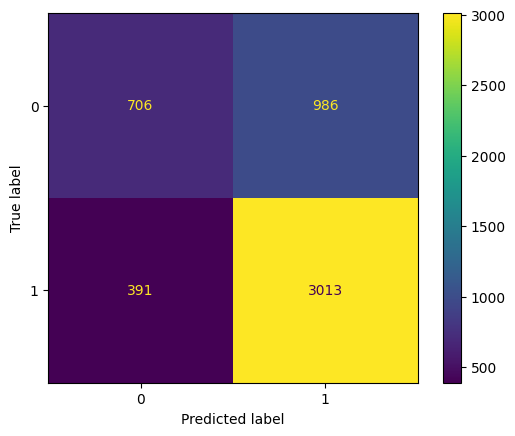

In [100]:
ConfusionMatrixDisplay.from_estimator(best_model, X_test_processed, y_test)

## Problem is FP. 
There are 986 FP. We can still reduce this by increasing the classification threshold. By default, it's 0.5. We can try 0.6 or 0.7 and see how it affects the metrics

In [102]:
y_probs = best_model.predict_proba(X_test_processed)[:, 1]

In [103]:
y_probs

array([0.8896189 , 0.94911784, 0.9241069 , ..., 0.3243083 , 0.40795377,
       0.97417295], shape=(5096,), dtype=float32)

In [110]:
for t in [0.5, 0.6, 0.7, 0.8]:
    y_pred_new = (y_probs >= t).astype(int)

    print("="*30)
    print(f"Threshold: {t}")
    print(confusion_matrix(y_test, y_pred_new))

Threshold: 0.5
[[ 706  986]
 [ 391 3013]]
Threshold: 0.6
[[ 904  788]
 [ 603 2801]]
Threshold: 0.7
[[1086  606]
 [ 960 2444]]
Threshold: 0.8
[[1345  347]
 [1516 1888]]


## Threshold Selection

### Selected Threshold: 0.6

In this problem, **recall is more important** because we want to correctly identify as many Certified cases as possible. However, we also aim to **reduce false positives (FP)** to avoid incorrect approvals.

After testing different thresholds, **0.6** was selected because:

- It reduces false positives compared to 0.5  
- It maintains good recall  
- It provides a balanced performance  

### Final Prediction Rule

If predicted probability ≥ 0.6 → Certified (1)  
Else → Denied (0)

In [117]:
best_model_final = xgb  
threshold = 0.6

In [118]:
y_probs = best_model.predict_proba(X_test_processed)[:, 1]

In [119]:
# Apply threshold
y_pred_final = (y_probs >= threshold).astype(int)

In [120]:

print(classification_report(y_test, y_pred_final))

              precision    recall  f1-score   support

           0       0.60      0.53      0.57      1692
           1       0.78      0.82      0.80      3404

    accuracy                           0.73      5096
   macro avg       0.69      0.68      0.68      5096
weighted avg       0.72      0.73      0.72      5096



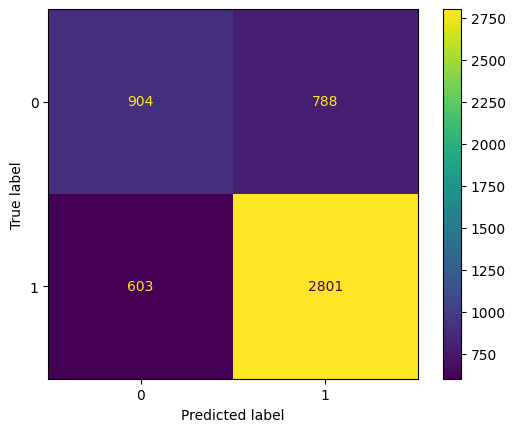

In [121]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_final)

## Recall Comparison (XGBoost)

| Model | Recall (Certified) |
|------|--------------------|
| XGBoost (Threshold = 0.5) | 0.885 |
| XGBoost (Threshold = 0.6) | 0.82 |

### Reason

- Recall is slightly lower at threshold 0.6  
- But false positives are reduced significantly  
- This provides a better balance for real-world use  

### Conclusion

Threshold 0.6 is selected to maintain good recall while reducing incorrect approvals.

In [122]:

joblib.dump(best_model_final, "final_model.pkl")

['final_model.pkl']

In [123]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [124]:
joblib.dump(0.6, "threshold.pkl")

['threshold.pkl']